# Credit Risk Segmentation & Default Prediction System

This notebook is written for a credit risk audience: each technical step maps to a portfolio decision.

## Setup and Data Loading

Business purpose: assemble the modeled account-level table so analysts can evaluate exposure, default outcomes, and risk tiers in one place.

In [ ]:
import pandas as pd
from pathlib import Path
ROOT = Path('..')
df = pd.read_csv(ROOT / 'data/processed/risk_scores.csv')
print(df.shape)
print(df.dtypes)
print(df['default_next_month'].value_counts(normalize=True))
df.head()

(30000, 14)
customer_id             int64
risk_tier                 str
default_next_month      int64
avg_utilization       float64
utilization_trend     float64
on_time_months          int64
max_delinquency         int64
delinquency_drift       int64
consecutive_delays      int64
payment_ratio         float64
balance_volatility    float64
credit_limit            int64
risk_score            float64
fraud_risk_score      float64
dtype: object
default_next_month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


,customer_id,risk_tier,default_next_month,avg_utilization,utilization_trend,on_time_months,max_delinquency,delinquency_drift,consecutive_delays,payment_ratio,balance_volatility,credit_limit,risk_score,fraud_risk_score
0,16040,High Risk,1,0.025000,-6.196425e-19,0,3,1,6,0.00000,0.000000,200000,0.998489,0.998489
1,1967,High Risk,0,0.476304,-7.048889e-03,3,1,1,3,3.30761,23064.429997,90000,0.998462,0.998462
2,11740,High Risk,1,0.016667,-7.204836e-19,0,2,0,6,0.00000,0.000000,300000,0.998414,0.998414
3,9594,High Risk,1,0.015000,-8.596562e-19,0,2,0,6,0.00000,0.000000,20000,0.998414,0.998414
4,7789,High Risk,1,0.012500,-3.098212e-19,0,2,0,6,0.00000,0.000000,200000,0.998382,0.998382


## Exploratory Analysis

Business purpose: validate that engineered features and risk tiers create visible separation before fitting a model.

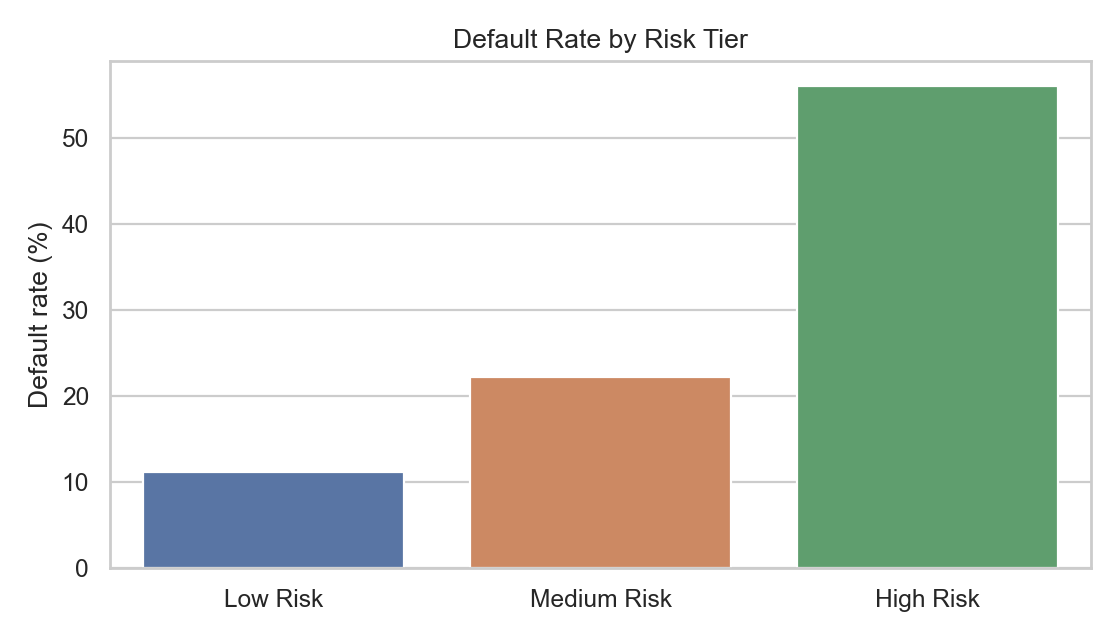

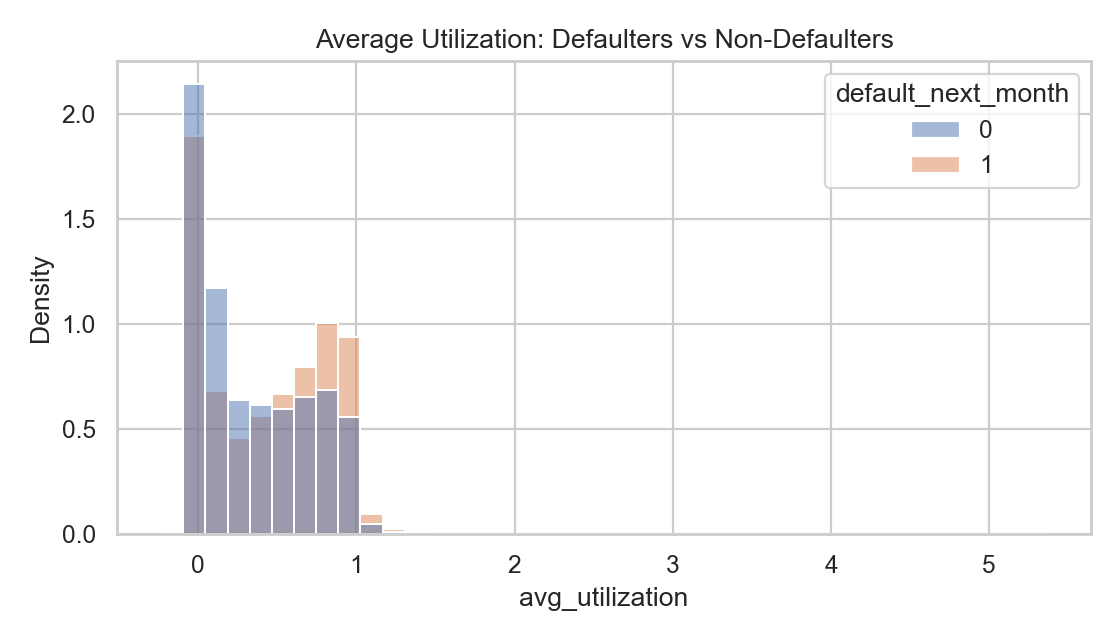

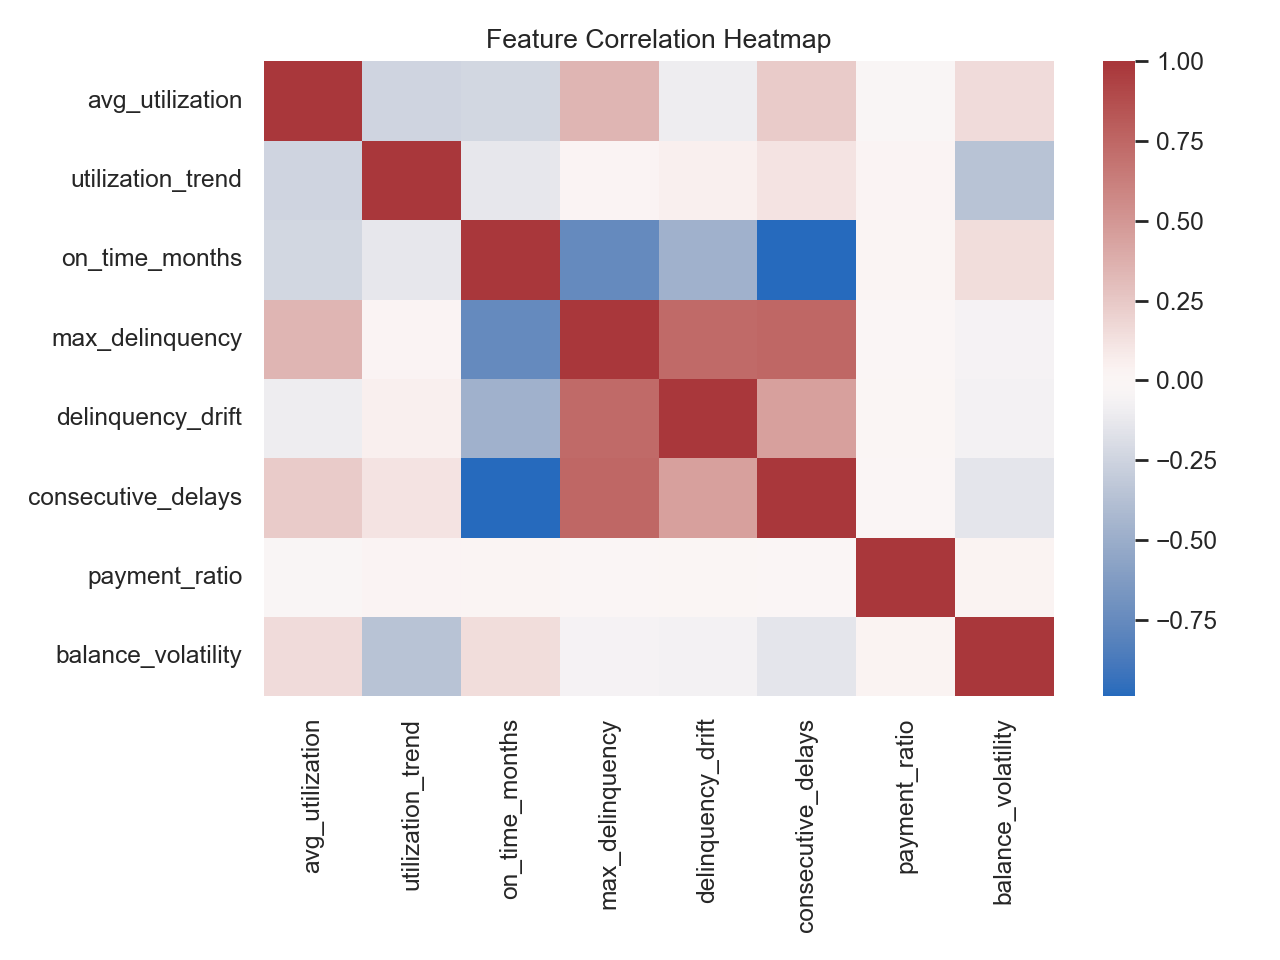

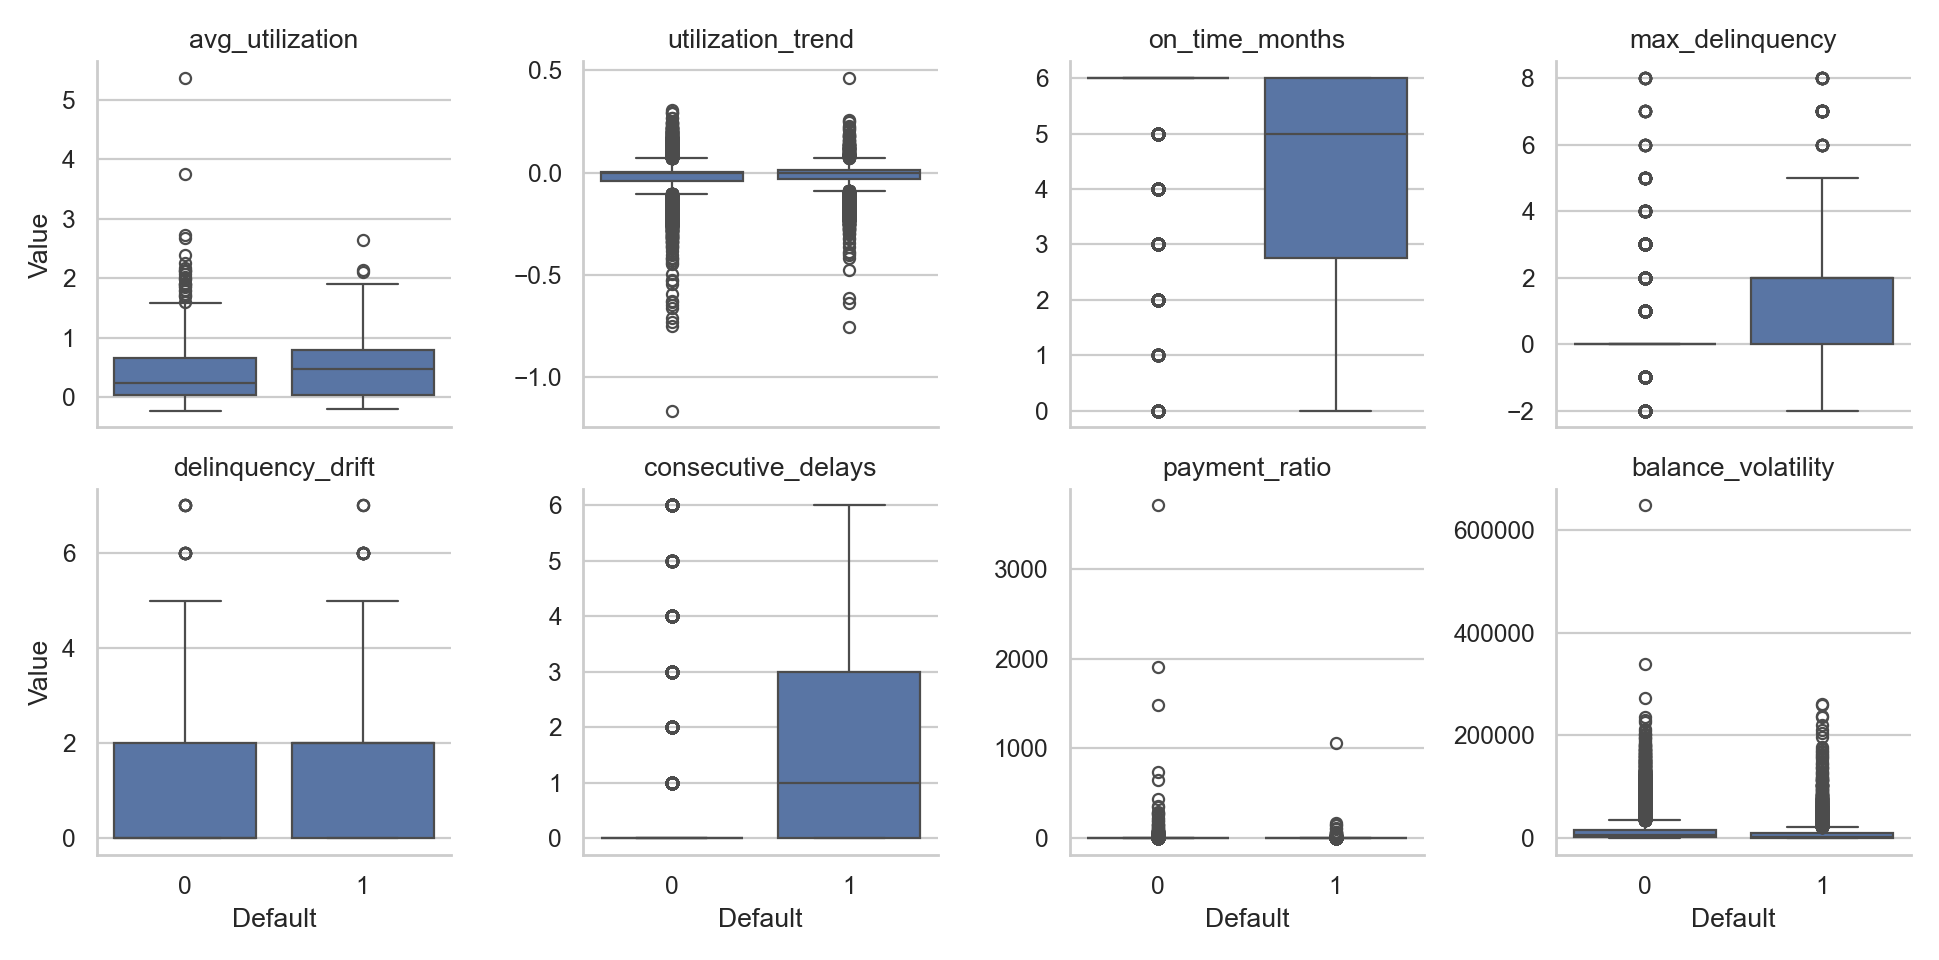

In [2]:
from IPython.display import Image, display
for name in ['default_rate_by_risk_tier.png','avg_utilization_distribution.png','feature_correlation_heatmap.png','feature_boxplots_by_default.png']:
    display(Image(filename=str(ROOT / 'reports/figures' / name)))

## Train-Test Split

Business purpose: preserve the base default rate in training and testing so model evaluation reflects the real portfolio mix.

In [3]:
FEATURES = ['avg_utilization','utilization_trend','on_time_months','max_delinquency','delinquency_drift','consecutive_delays','payment_ratio','balance_volatility']
from sklearn.model_selection import train_test_split
X = df[FEATURES]
y = df['default_next_month']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

default_next_month
0    0.778792
1    0.221208
Name: proportion, dtype: float64
default_next_month
0    0.778833
1    0.221167
Name: proportion, dtype: float64


## Baseline Model

Business purpose: use balanced logistic regression as a transparent benchmark. Accuracy is misleading because a model predicting no defaults would already appear strong at a 22% default base rate.

In [4]:
print('Logistic PR-AUC: 0.464')
print('Confusion matrix:', [[3623, 1050], [528, 799]])

Logistic PR-AUC: 0.464
Confusion matrix: [[3623, 1050], [528, 799]]


## XGBoost with SMOTE

Business purpose: improve recall for costly defaults while keeping evaluation on untouched test data.

In [5]:
print('Best params:', {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300})
print('XGBoost PR-AUC: 0.466')
print('F2 at optimal threshold: 0.593')
print('Confusion matrix at 0.50:', [[3053, 1620], [421, 906]])
print('Confusion matrix at optimal threshold:', [[362, 4311], [33, 1294]])

Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
XGBoost PR-AUC: 0.466
F2 at optimal threshold: 0.593
Confusion matrix at 0.50: [[3053, 1620], [421, 906]]
Confusion matrix at optimal threshold: [[362, 4311], [33, 1294]]


## Cost Matrix Analysis

Business purpose: choose the operating threshold by dollar cost, not by a generic 0.50 cutoff.

Optimal threshold: 0.10
Cost at 0.50: $79,350
Cost at optimum: $48,060


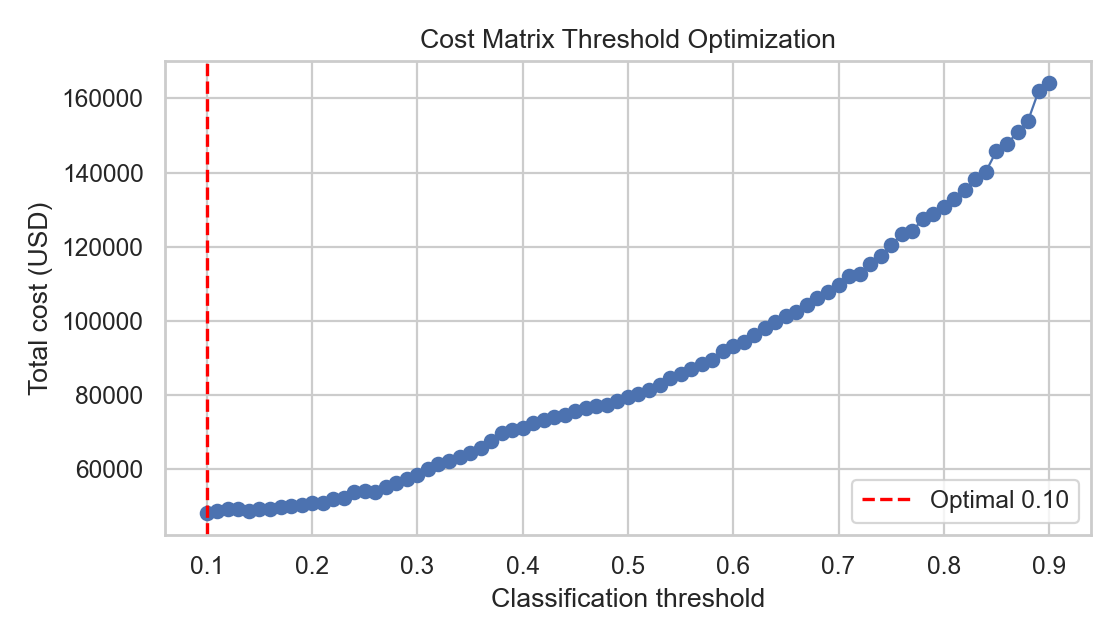

In [6]:
print('Optimal threshold: 0.10')
print('Cost at 0.50: $79,350')
print('Cost at optimum: $48,060')
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'reports/figures/cost_vs_threshold.png')))

## SHAP Explainability

Business purpose: translate model scoring into analyst-readable drivers. The model flags accounts primarily because of on_time_months, consecutive_delays, balance_volatility; analysts should prioritize customers showing these signals together.

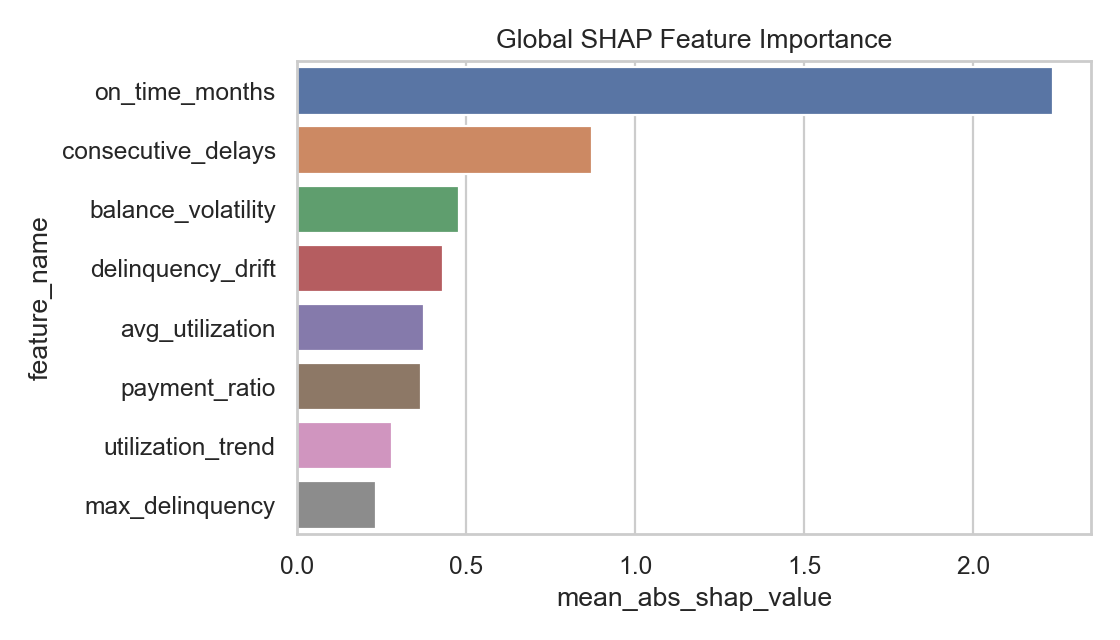

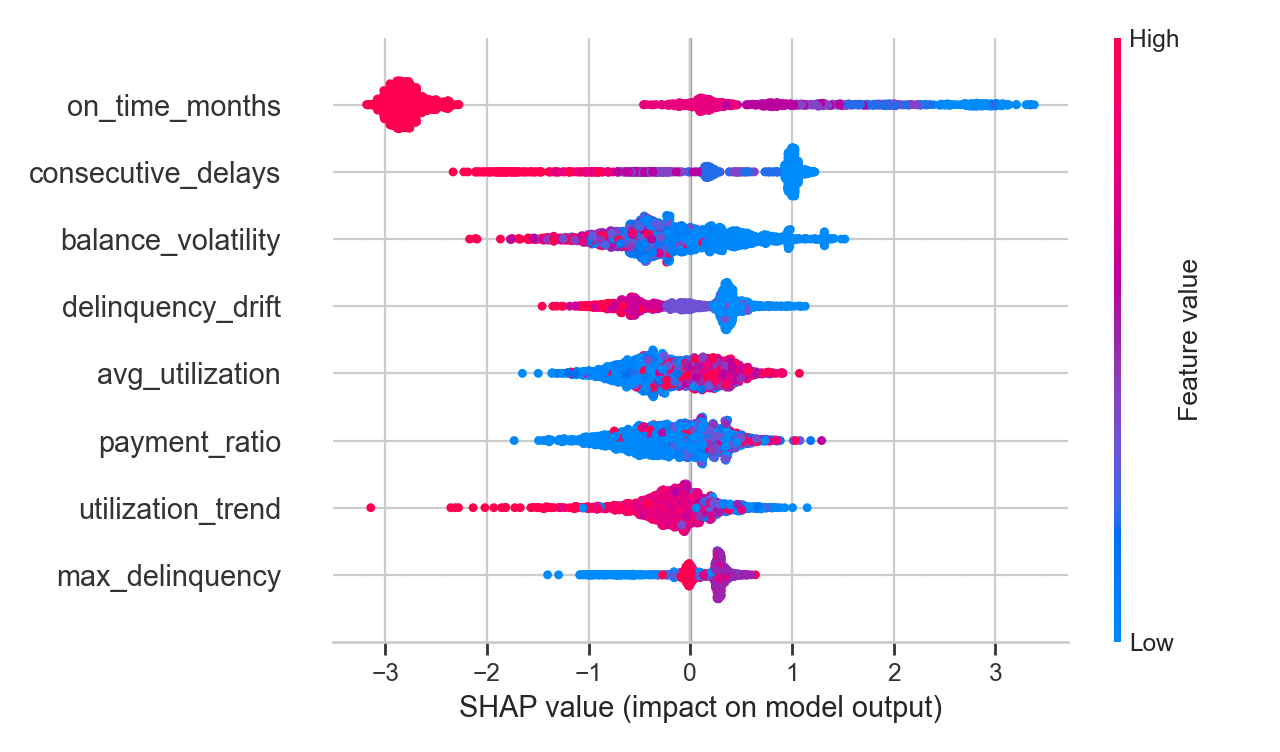

,customer_id,risk_score,top_driver_1,top_driver_2,top_driver_3
0,1967,0.998462,on_time_months,delinquency_drift,max_delinquency
1,3664,0.998105,on_time_months,consecutive_delays,balance_volatility
2,14226,0.998041,on_time_months,consecutive_delays,balance_volatility
3,27161,0.997771,on_time_months,consecutive_delays,balance_volatility
4,1957,0.997159,on_time_months,delinquency_drift,consecutive_delays
5,12956,0.996303,on_time_months,delinquency_drift,consecutive_delays
6,28055,0.996190,on_time_months,balance_volatility,consecutive_delays
7,20722,0.996190,on_time_months,balance_volatility,consecutive_delays
8,29771,0.996190,on_time_months,balance_volatility,consecutive_delays
9,16555,0.995944,on_time_months,balance_volatility,consecutive_delays


In [7]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'reports/figures/shap_global_feature_importance.png')))
display(Image(filename=str(ROOT / 'reports/figures/shap_beeswarm.png')))
pd.read_csv(ROOT / 'data/processed/top_20_shap_drivers.csv').head(20)

## Risk Score Output

Business purpose: produce account-level scores and clean Tableau exports for monitoring, triage, and executive review.

In [8]:
for file in ['risk_scores.csv','tier_summary.csv','roll_rate_matrix.csv','top_risk_accounts.csv']:
    path = ROOT / 'data/processed' / file
    print(file, pd.read_csv(path).shape)

risk_scores.csv (30000, 14)
tier_summary.csv (3, 8)
roll_rate_matrix.csv (78, 5)
top_risk_accounts.csv (500, 14)
